# POS Hypothesis Explorer

-

## Important comparability note

-

## How to use

1. Make sure your experiment JSON outputs exist under `resources/results/`.
2. Adjust `PROJECT_ROOT` below if needed.
3. Run all cells from top to bottom.
4. Use `SELECTION_METRIC` near the top to choose how “best” is defined.

Recommended metrics:
- `f1` for overall model quality
- `token_accuracy` for straightforward token-level comparison
- `best_val_accuracy` to inspect validation performance


In [11]:
from pathlib import Path

# Adjust if needed
PROJECT_ROOT = Path("/home/dan-gavriluta/Coding/ml-project")
RESULTS_ROOT = PROJECT_ROOT / "resources" / "results"
MODELS_ROOT = PROJECT_ROOT / "resources" / "models"

SELECTION_METRIC = "f1"  # options: f1, token_accuracy, precision, recall, best_val_accuracy

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)
print("Exists:", RESULTS_ROOT.exists())


PROJECT_ROOT: /home/dan-gavriluta/Coding/ml-project
RESULTS_ROOT: /home/dan-gavriluta/Coding/ml-project/resources/results
Exists: True


In [12]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)
sns.set_theme(style="whitegrid")

def load_all_result_files(results_root: Path):
    return sorted(results_root.rglob("training_results.json"))

def load_all_runs(results_root: Path):
    files = load_all_result_files(results_root)
    runs = []
    for fp in files:
        with fp.open("r", encoding="utf-8") as f:
            payload = json.load(f)
        if isinstance(payload, dict):
            payload = [payload]
        for run in payload:
            run["_results_file"] = str(fp)
            run["_results_folder"] = str(fp.parent)
            runs.append(run)
    return files, runs

def flatten_run(run):
    row = {
        "name": run.get("name"),
        "model_type": run.get("model_type"),
        "best_val_accuracy": run.get("best_val_accuracy"),
        "best_val_loss": run.get("best_val_loss"),
        "train_time_sec": run.get("train_time_sec"),
        "num_params": run.get("num_params"),
        "epochs_ran": run.get("epochs_ran"),
        "model_path": run.get("model_path"),
        "model_saved": run.get("model_saved"),
        "_results_file": run.get("_results_file"),
        "_results_folder": run.get("_results_folder"),
    }

    tm = run.get("test_metrics", {})
    for k, v in tm.items():
        row[k] = v

    cfg = run.get("config", {})
    for k, v in cfg.items():
        row[f"cfg_{k}"] = v

    dm = run.get("dataset_meta", {})
    row["group"] = cfg.get("group")
    row["hypothesis"] = cfg.get("hypothesis")
    row["sentences"] = dm.get("sentences", cfg.get("sentences"))
    row["maxlen"] = dm.get("maxlen", cfg.get("maxlen"))
    row["split_seed"] = dm.get("split_seed", cfg.get("split_seed"))
    row["run_seed"] = dm.get("seed", cfg.get("seed"))
    row["vocab_size"] = dm.get("vocab_size", cfg.get("vocab_size"))
    row["num_tags"] = dm.get("num_tags", cfg.get("num_tags"))

    return row

def runs_to_df(runs):
    if not runs:
        return pd.DataFrame()
    df = pd.DataFrame([flatten_run(r) for r in runs])

    numeric_cols = [
        "best_val_accuracy", "best_val_loss", "train_time_sec", "num_params", "epochs_ran",
        "token_accuracy", "precision", "recall", "f1",
        "sentences", "maxlen", "split_seed", "run_seed", "vocab_size", "num_tags",
        "cfg_lr", "cfg_dropout", "cfg_batch_size", "cfg_embed_dim", "cfg_ff_dim",
        "cfg_num_layers", "cfg_num_heads", "cfg_lstm_units", "cfg_lstm_layers",
        "cfg_lr_warmup_steps",
    ]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def get_group(df, group_name):
    return df[df["group"] == group_name].copy()

def show_top(df, metric="f1", n=10):
    cols = [
        "name", "group", "model_type", metric,
        "token_accuracy", "best_val_accuracy", "train_time_sec",
        "num_params", "sentences", "maxlen", "split_seed", "run_seed"
    ]
    cols = [c for c in cols if c in df.columns]
    return df.sort_values(metric, ascending=False)[cols].head(n).reset_index(drop=True)

def plot_bar(df_group, metric="f1", title=None, hue="model_type", figsize=(12, 5)):
    if df_group.empty:
        print("No rows for this plot.")
        return
    order = df_group.sort_values(metric, ascending=False)["name"]
    plt.figure(figsize=figsize)
    sns.barplot(data=df_group, x="name", y=metric, hue=hue, order=order)
    plt.xticks(rotation=35, ha="right")
    plt.title(title or f"{metric} by run")
    plt.tight_layout()
    plt.show()

def plot_line(df_group, x, y="f1", hue="model_type", marker="o", title=None, figsize=(10, 5)):
    if df_group.empty:
        print("No rows for this plot.")
        return
    plt.figure(figsize=figsize)
    sns.lineplot(data=df_group.sort_values([hue, x]), x=x, y=y, hue=hue, marker=marker)
    plt.title(title or f"{y} vs {x}")
    plt.tight_layout()
    plt.show()

def plot_histories(runs, group_name, metric="val_accuracy", figsize=(10, 5)):
    plt.figure(figsize=figsize)
    used = False
    for run in runs:
        cfg = run.get("config", {})
        if cfg.get("group") != group_name:
            continue
        hist = run.get("history", {})
        vals = hist.get(metric, [])
        if vals:
            used = True
            plt.plot(range(1, len(vals) + 1), vals, label=run.get("name"))
    if not used:
        print("No history found for this group/metric.")
        return
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"{group_name}: {metric}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def annotate_scatter(df_group, x="train_time_sec", y="f1", figsize=(8, 5), title=None):
    if df_group.empty:
        print("No rows for this plot.")
        return
    plt.figure(figsize=figsize)
    sns.scatterplot(data=df_group, x=x, y=y, hue="model_type", s=80)
    for _, row in df_group.iterrows():
        plt.annotate(row["name"], (row[x], row[y]), fontsize=8)
    plt.title(title or f"{y} vs {x}")
    plt.tight_layout()
    plt.show()

def grouped_summary(df_group, by, metric="f1"):
    if df_group.empty:
        return pd.DataFrame()
    return (
        df_group.groupby(by, dropna=False)[metric]
        .agg(["count", "mean", "std", "min", "max"])
        .sort_values("mean", ascending=False)
        .reset_index()
    )

def heatmap_split_seed_vs_run_seed(df_group, metric="f1", model_type=None, figsize=(6, 5)):
    temp = df_group.copy()
    if model_type is not None:
        temp = temp[temp["model_type"] == model_type]
    if temp.empty:
        print("No rows for this heatmap.")
        return
    pivot = temp.pivot_table(index="split_seed", columns="run_seed", values=metric, aggfunc="mean")
    plt.figure(figsize=figsize)
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis")
    title = f"{metric} heatmap"
    if model_type:
        title += f" — {model_type}"
    plt.title(title)
    plt.tight_layout()
    plt.show()

def practical_score(df, metric="f1", time_penalty=0.001):
    out = df.copy()
    out["practical_score"] = out[metric] - time_penalty * out["train_time_sec"].fillna(0)
    return out

files, runs = load_all_runs(RESULTS_ROOT)
df = runs_to_df(runs)

print(f"Found {len(files)} result file(s)")
print(f"Loaded {len(runs)} run(s)")

Found 3 result file(s)
Loaded 30 run(s)


In [13]:
if df.empty:
    print("No results found. Run experiments first.")
else:
    display(Markdown("### Discovered result files"))
    display(pd.DataFrame({"results_file": [str(f) for f in files]}))

    display(Markdown("### Overall top runs"))
    display(show_top(df, metric=SELECTION_METRIC, n=15))

    display(Markdown("### Run counts by group"))
    group_counts = df.groupby(["group", "model_type"]).size().reset_index(name="runs")
    display(group_counts.sort_values(["group", "model_type"]).reset_index(drop=True))


### Discovered result files

,results_file
0,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_1_high_lr_sent/training_results.json
1,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_1_low_lr_sent/training_results.json
2,/home/dan-gavriluta/Coding/ml-project/resources/results/hypothesis_1_medium_lr_sent/training_results.json


### Overall top runs

,name,group,model_type,f1,token_accuracy,best_val_accuracy,train_time_sec,num_params,sentences,maxlen,split_seed,run_seed
0,A_lstm_stronger_smax,A_baseline_family_comparison,lstm,0.923832,0.924360,0.925386,72.856640,2450707,12543,30,42,42
1,A_lstm_stronger_s10000,A_baseline_family_comparison,lstm,0.921627,0.922145,0.921059,46.989417,2230419,10000,30,42,42
2,A_lstm_stronger_s7000,A_baseline_family_comparison,lstm,0.916328,0.917241,0.918269,34.742278,1896083,7000,30,42,42
3,A_lstm_stronger_s5000,A_baseline_family_comparison,lstm,0.906864,0.907268,0.919126,29.031315,1490323,5000,30,42,42
4,A_lstm_stronger_smax,A_baseline_family_comparison,lstm,0.901433,0.904332,0.901297,114.739365,2450707,12543,30,42,42
5,A_lstm_stronger_s10000,A_baseline_family_comparison,lstm,0.880179,0.886057,0.884220,66.970000,2230419,10000,30,42,42
6,A_transformer_medium_smax,A_baseline_family_comparison,transformer,0.870741,0.871729,0.937834,26.288718,2584979,12543,30,42,42
7,A_transformer_medium_smax,A_baseline_family_comparison,transformer,0.867928,0.869114,0.936489,31.230569,2584979,12543,30,42,42
8,A_transformer_medium_s10000,A_baseline_family_comparison,transformer,0.862785,0.863638,0.935875,11.012479,2364691,10000,30,42,42
9,A_transformer_medium_s10000,A_baseline_family_comparison,transformer,0.861870,0.863176,0.934229,16.080062,2364691,10000,30,42,42


### Run counts by group

,group,model_type,runs
0,A_baseline_family_comparison,lstm,15
1,A_baseline_family_comparison,transformer,15


## Overall interpretation guide

Use these rules while reading the plots:

- **Higher `f1` / `token_accuracy` is better**
- **Lower `best_val_loss` is better**
- **Lower `train_time_sec` is better**
- If one family wins by only a tiny margin but is much slower, check the practical tradeoff
- For groups that vary data size or max length, compare trends, not just one isolated bar
- For robustness, prefer **mean performance + low variance** over one lucky best run


In [14]:
leaderboard_cols = [
    "name", "group", "model_type",
    "token_accuracy", "f1", "precision", "recall",
    "best_val_accuracy", "best_val_loss",
    "train_time_sec", "epochs_ran",
]

config_cols = [
    "name", "model_type",
    "num_params",
    "cfg_embed_dim", "cfg_num_heads", "cfg_ff_dim", "cfg_num_layers",
    "cfg_lstm_units", "cfg_lstm_layers", "cfg_dropout", "cfg_lr",
    "cfg_lr_warmup_steps", "cfg_batch_size",
]

meta_cols = [
    "name", "model_type",
    "sentences", "maxlen", "split_seed", "run_seed",
    "vocab_size", "num_tags",
    "predict_batch_size_used", "predict_device",
]

# Hypothesis 1 — ###

**Hypothesis**  
###

**Controlled factors**
- ###

**What to look for**
- ###

In [15]:
# Filter data for Hypothesis 1
h1_data = df[df["hypothesis"] == "H1_transformer_beats_lstm_default"].copy()

if h1_data.empty:
    print("No H1 data found yet. Run experiments with hypothesis='H1_transformer_beats_lstm_default' in config.")
else:
    print(f"Found {len(h1_data)} runs for Hypothesis 1")
    display(Markdown("### Hypothesis 1 — All runs"))
    display_cols = [
        "name", "model_type", "sentences", "cfg_lr",
        "f1", "token_accuracy", "best_val_accuracy",
        "train_time_sec", "num_params"
    ]
    display_cols = [c for c in display_cols if c in h1_data.columns]
    display(h1_data[display_cols].sort_values(["sentences", "cfg_lr", "model_type"]).reset_index(drop=True))

Found 30 runs for Hypothesis 1


### Hypothesis 1 — All runs

,name,model_type,sentences,cfg_lr,f1,token_accuracy,best_val_accuracy,train_time_sec,num_params
0,A_lstm_baseline,lstm,2000,0.00001,0.115131,0.169583,0.172080,11.862056,258835
1,A_transformer_small,transformer,2000,0.00001,0.151919,0.137431,0.495208,8.843458,225203
2,A_lstm_baseline,lstm,2000,0.00010,0.114827,0.209987,0.217298,12.234961,258835
3,A_transformer_small,transformer,2000,0.00010,0.643788,0.658700,0.796667,9.431216,225203
4,A_lstm_baseline,lstm,2000,0.00100,0.797213,0.813345,0.803876,12.326847,258835
5,A_transformer_small,transformer,2000,0.00100,0.824020,0.825864,0.900833,9.475419,225203
6,A_lstm_stronger_s5000,lstm,5000,0.00001,0.116445,0.218380,0.223406,34.377805,1490323
7,A_transformer_medium_s5000,transformer,5000,0.00001,0.575911,0.592352,0.818708,20.694713,1624595
8,A_lstm_stronger_s5000,lstm,5000,0.00010,0.707496,0.738262,0.745173,35.404147,1490323
9,A_transformer_medium_s5000,transformer,5000,0.00010,0.849977,0.850356,0.934625,23.551025,1624595


### Interpretation

**Expected outcomes:**
1. **Learning rate preference**:
   - LSTM should perform best at higher LR (e.g., 1e-3)
   - Transformer should perform best at lower LR (e.g., 1e-4 or 5e-4)

2. **Data scaling**:
   - At low data (500-2000 sentences): LSTM and Transformer should be competitive
   - At high data (5000-12543 sentences): Transformer should pull ahead significantly
   - The gap should widen as data increases

3. **Combined effect**:
   - Transformer at low LR + high data should be the winning combination
   - LSTM's advantage (if any) should be limited to high LR + low data scenarios

### Visualization 3: Heatmap of LR × Data Size

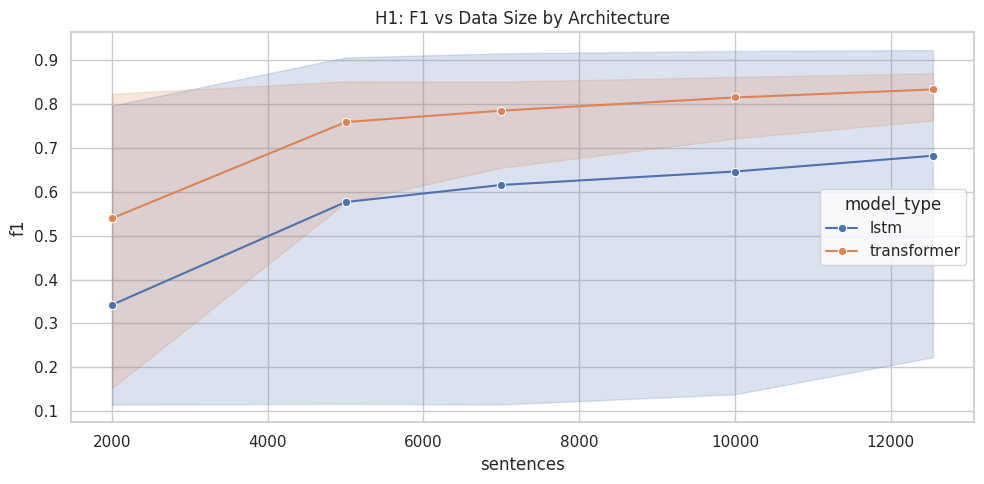

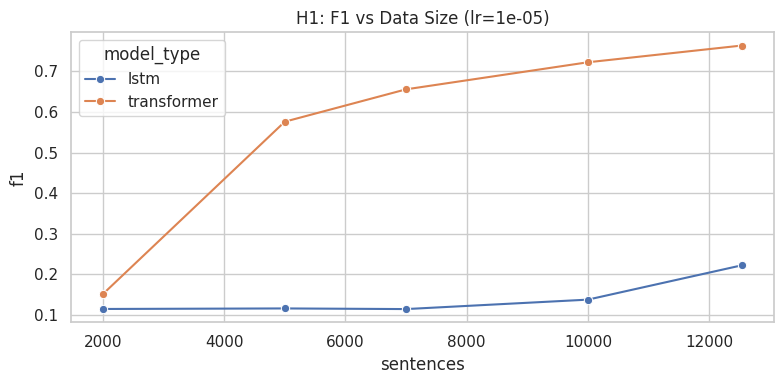

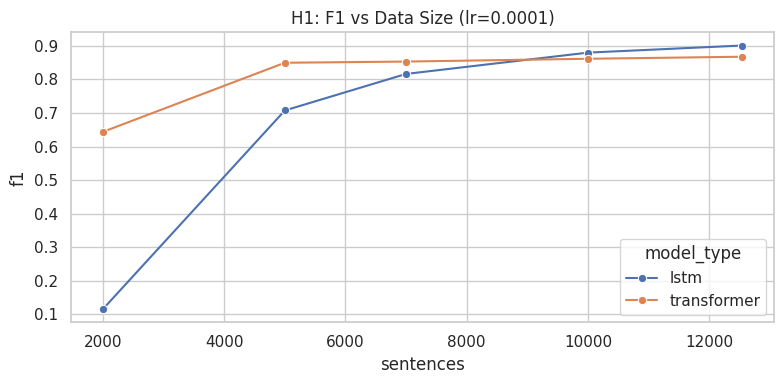

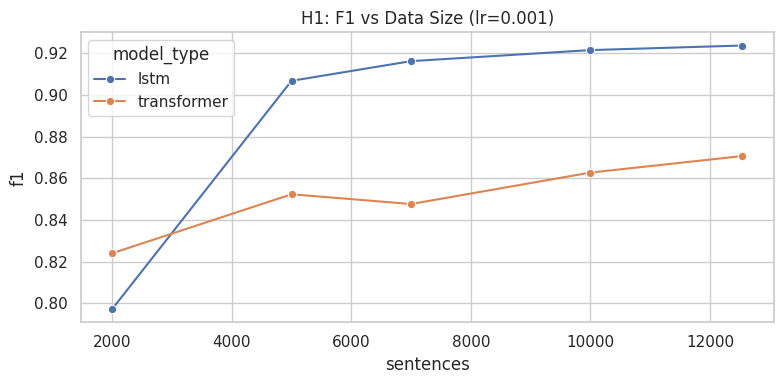

In [17]:
if not h1_data.empty:
    plot_line(
        h1_data,
        x="sentences",
        y=SELECTION_METRIC,
        hue="model_type",
        title=f"H1: {SELECTION_METRIC.upper()} vs Data Size by Architecture",
        figsize=(10, 5)
    )

    # Also show for each learning rate separately
    for lr in sorted(h1_data["cfg_lr"].unique()):
        subset = h1_data[h1_data["cfg_lr"] == lr]
        if len(subset) > 0:
            plot_line(
                subset,
                x="sentences",
                y=SELECTION_METRIC,
                hue="model_type",
                title=f"H1: {SELECTION_METRIC.upper()} vs Data Size (lr={lr})",
                figsize=(8, 4)
            )

### Visualization 2: Data scaling behavior

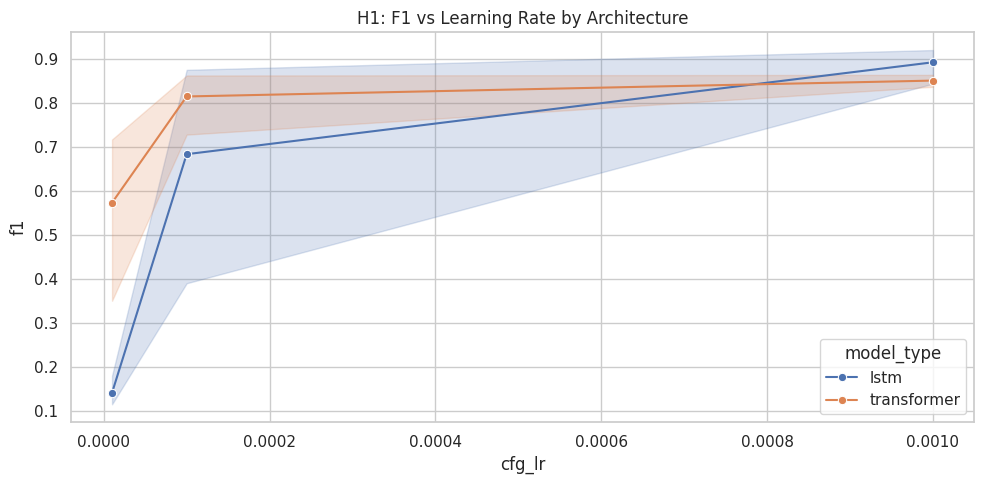

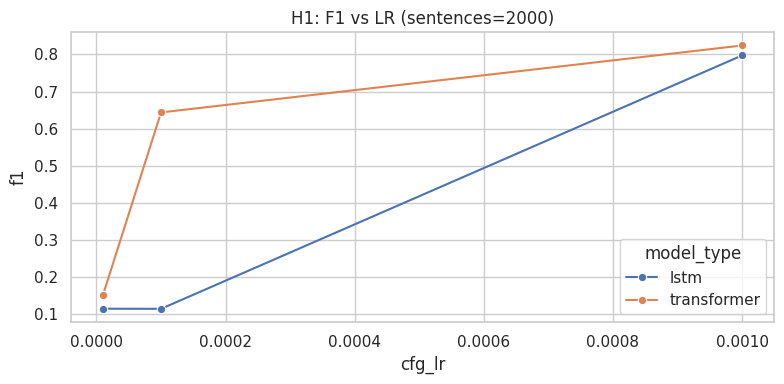

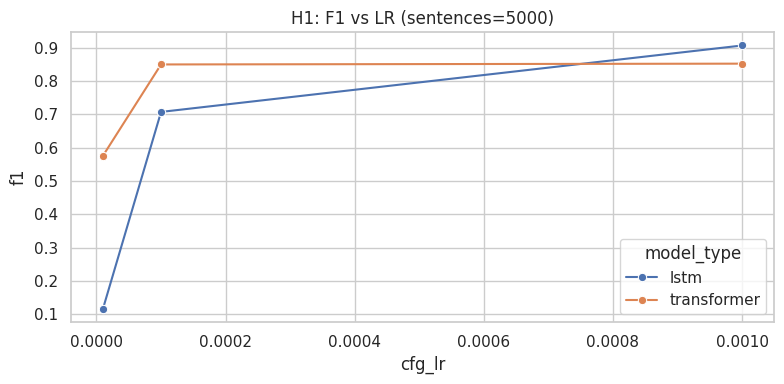

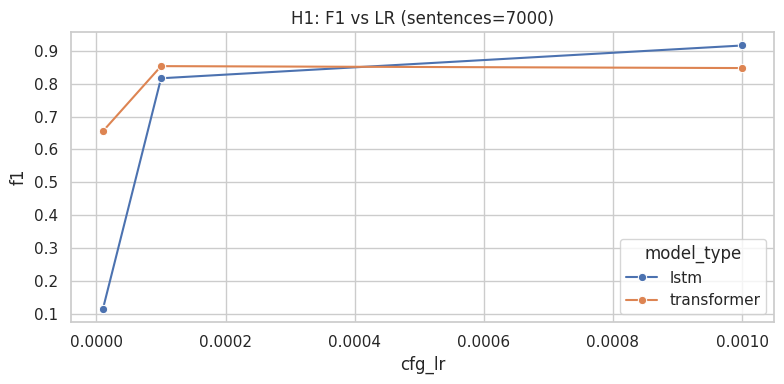

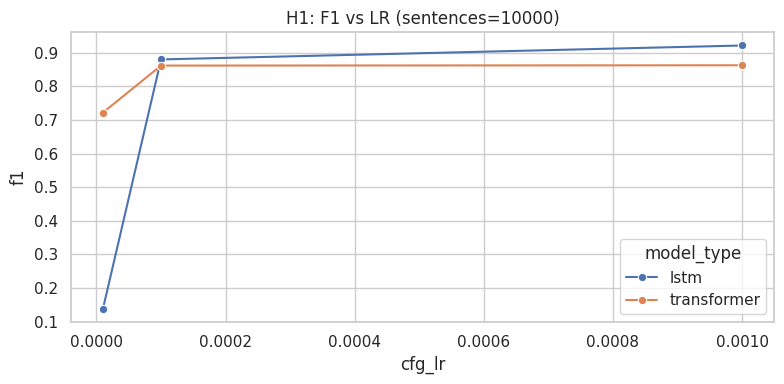

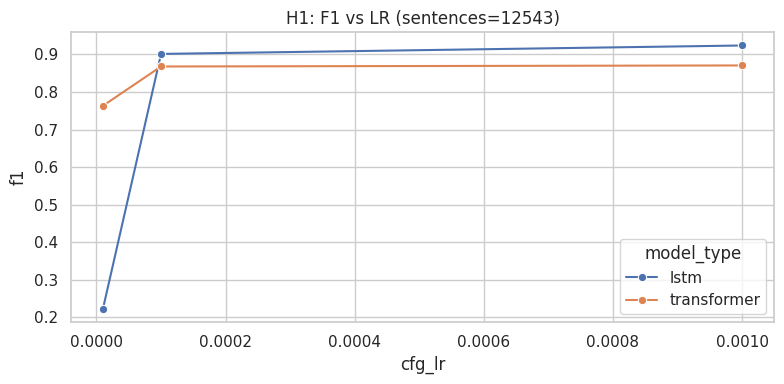

In [18]:
if not h1_data.empty:
    plot_line(
        h1_data,
        x="cfg_lr",
        y=SELECTION_METRIC,
        hue="model_type",
        title=f"H1: {SELECTION_METRIC.upper()} vs Learning Rate by Architecture",
        figsize=(10, 5)
    )

    # Also show for each data size separately
    for sent_count in sorted(h1_data["sentences"].unique()):
        subset = h1_data[h1_data["sentences"] == sent_count]
        if len(subset) > 0:
            plot_line(
                subset,
                x="cfg_lr",
                y=SELECTION_METRIC,
                hue="model_type",
                title=f"H1: {SELECTION_METRIC.upper()} vs LR (sentences={sent_count})",
                figsize=(8, 4)
            )

### Final tables 

In [ ]:
if not h1_data.empty:
    # Summary by model type and learning rate
    display(Markdown("#### By model type and learning rate"))
    lr_summary = grouped_summary(h1_data, by=["model_type", "cfg_lr"], metric=SELECTION_METRIC)
    display(lr_summary)

    # Summary by model type and sentence count
    display(Markdown("#### By model type and sentence count"))
    data_summary = grouped_summary(h1_data, by=["model_type", "sentences"], metric=SELECTION_METRIC)
    display(data_summary)

#### By model type and learning rate

,model_type,cfg_lr,count,mean,std,min,max
0,lstm,0.00100,5,0.893173,0.054040,0.797213,0.923832
1,transformer,0.00100,5,0.851520,0.017805,0.824020,0.870741
2,transformer,0.00010,5,0.815417,0.096201,0.643788,0.867928
3,lstm,0.00010,5,0.684109,0.327055,0.114827,0.901433
4,transformer,0.00001,5,0.573747,0.246257,0.151919,0.763323
5,lstm,0.00001,5,0.141452,0.046457,0.114891,0.222681


#### By model type and sentence count

,model_type,sentences,count,mean,std,min,max
0,transformer,12543,3,0.833998,0.061222,0.763323,0.870741
1,transformer,10000,3,0.815580,0.080971,0.722084,0.862785
2,transformer,7000,3,0.785570,0.112681,0.655500,0.853524
3,transformer,5000,3,0.759419,0.158927,0.575911,0.852368
4,lstm,12543,3,0.682649,0.398501,0.222681,0.923832
5,lstm,10000,3,0.646639,0.440885,0.138112,0.921627
6,lstm,7000,3,0.615943,0.436778,0.114891,0.916328
7,lstm,5000,3,0.576935,0.411066,0.116445,0.906864
8,transformer,2000,3,0.539909,0.347884,0.151919,0.824020
9,lstm,2000,3,0.342390,0.393888,0.114827,0.797213


### Summary: Performance by learning rate and data size